<div align="center">

# <h1> **Email Spam Classifier Notebook** </h1>

**Author:**  
**APDOOLMAJEED HAMZA (apdoolhamza)**  
<a href="https://www.linkedin.com/in/apdoolhamza">LinkedIn</a>

---

**Project:**  
<a href="https://github.com/apdoolhamza/SMS-Email-Spam-Detector/blob/main/Docs/SMS_Email_Spam_Classifier.pdf">Full Documentation</a> |  
<a href="https://huggingface.co/spaces/apdoolhamza/SMS-Email-Spam-Detector">Live Demo</a> |  
<a href="https://github.com/apdoolhamza/SMS-Email-Spam-Detector">GitHub</a>

</div>

# Install & Imports libraries

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn wordcloud nltk clean-text joblib -q

import nltk
nltk.download(['punkt', 'punkt_tab', 'wordnet', 'stopwords', 'omw-1.4'], quiet=True)
print("Setup complete.")

Setup complete.


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, cross_val_score, HalvingGridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from cleantext import clean
import joblib
import warnings
# warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print("Spam section imports ready.")

Spam section imports ready.


In [ ]:
url_spam = "https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"

df_spam = pd.read_csv(url_spam, encoding='latin-1')
df_spam = df_spam[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df_spam['label'] = df_spam['label'].map({'ham': 0, 'spam': 1})

print("Shape:", df_spam.shape)
print("\nClass distribution:\n", df_spam['label'].value_counts(normalize=True).round(4))
print("\nFirst few rows:")
print(df_spam.head(6))

Shape: (5572, 2)

Class distribution:
 label
0    0.8659
1    0.1341
Name: proportion, dtype: float64

First few rows:
   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
5      1  FreeMsg Hey there darling it's been 3 week's n...


# Load & Prepare Data

# Text Cleaning

In [ ]:
def professional_clean(text):
    text = clean(text, lower=True, no_line_breaks=True, no_urls=True,
                 no_emails=True, no_phone_numbers=True, no_numbers=False,
                 no_punct=False, replace_with_punct="")
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]
    return ' '.join(tokens)

df_spam['clean_text'] = df_spam['text'].apply(professional_clean)

# Add Spam-specific Engineered Features (very effective for short messages)

In [ ]:
df_spam['length']      = df_spam['clean_text'].str.len()
df_spam['word_count']  = df_spam['clean_text'].str.split().str.len()
df_spam['has_free']    = df_spam['clean_text'].str.contains(r'\bfree\b', case=False, regex=True).astype(int)
df_spam['has_win']     = df_spam['clean_text'].str.contains(r'\bwin|won|prize\b', case=False, regex=True).astype(int)
df_spam['exclamation'] = df_spam['text'].str.count('!').clip(upper=15)  # cap outliers

print("Engineered features added. Sample:")
print(df_spam[['clean_text', 'length', 'word_count', 'has_free', 'has_win', 'exclamation', 'label']].head(6))

Engineered features added. Sample:
                                          clean_text  length  word_count  \
0  jurong point crazy available bugis great world...      72          12   
1                                 lar joking wif oni      18           4   
2  free entry wkly comp win cup final tkts may te...      97          17   
3                      dun say early hor already say      29           6   
4           nah dont think go usf life around though      40           8   
5  freemsg hey darling week word back like fun st...      71          14   

   has_free  has_win  exclamation  label  
0         0        0            0      0  
1         0        0            0      0  
2         1        1            0      1  
3         0        0            0      0  
4         0        0            0      0  
5         0        0            2      1  


# EDA & Visualizations


# Class balance

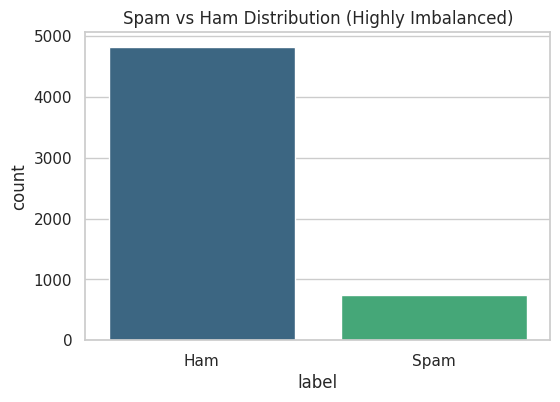

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_spam['label'], hue=df_spam['label'], palette='viridis', legend=False)
plt.xticks([0,1], ['Ham', 'Spam'])
plt.title("Spam vs Ham Distribution (Highly Imbalanced)")
plt.show()

# Text length by class

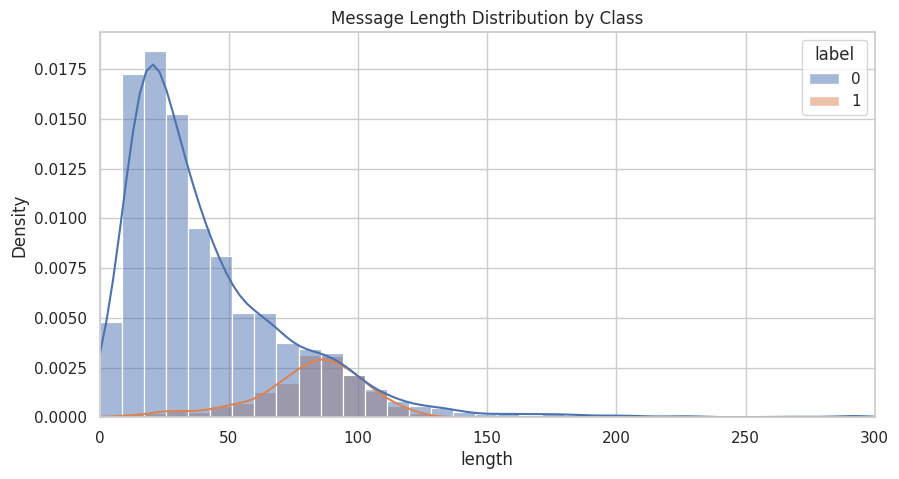

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_spam, x='length', hue='label', bins=60, kde=True, stat='density')
plt.title("Message Length Distribution by Class")
plt.xlim(0, 300)
plt.show()

# Word clouds

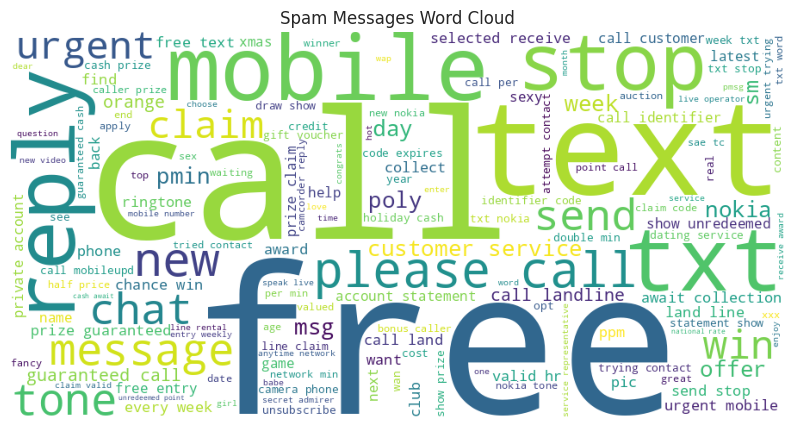

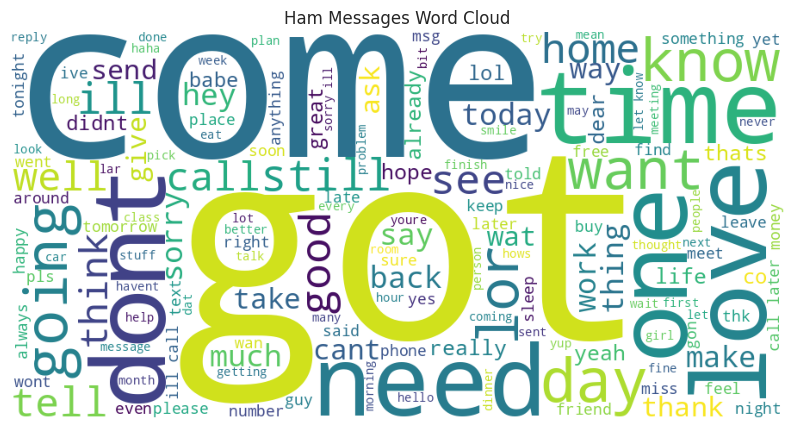

In [ ]:
def show_wordcloud(texts, title):
    if len(texts) == 0: return
    wc = WordCloud(width=900, height=450, background_color='white', max_words=150).generate(' '.join(texts))
    plt.figure(figsize=(10,6))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(title)
    plt.show()

spam_texts = df_spam[df_spam['label']==1]['clean_text']
ham_texts  = df_spam[df_spam['label']==0]['clean_text']

show_wordcloud(spam_texts, "Spam Messages Word Cloud")
show_wordcloud(ham_texts,  "Ham Messages Word Cloud")

# Train / Test Split

In [ ]:
text_col = 'clean_text'
num_cols = ['length', 'word_count', 'has_free', 'has_win', 'exclamation']

X = df_spam[[text_col] + num_cols]
y = df_spam['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

Train: 4,457   Test: 1,115


# Pipeline Definition

In [ ]:
preprocessor = ColumnTransformer([
    ('tfidf', TfidfVectorizer(max_features=18000, ngram_range=(1,2), min_df=3, sublinear_tf=True), text_col),
    ('num',    StandardScaler(), num_cols)
])

pipe_spam = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        solver='lbfgs'
    ))
])

# Cross-validation

In [ ]:
cv_f1 = cross_val_score(pipe_spam, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
cv_prec = cross_val_score(pipe_spam, X_train, y_train, cv=5, scoring='precision', n_jobs=-1)
cv_rec = cross_val_score(pipe_spam, X_train, y_train, cv=5, scoring='recall', n_jobs=-1)

print(f"CV F1       : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"CV Precision: {cv_prec.mean():.4f} ± {cv_prec.std():.4f}")
print(f"CV Recall   : {cv_rec.mean():.4f} ± {cv_rec.std():.4f}")

CV F1       : 0.8351 ± 0.0239
CV Precision: 0.7736 ± 0.0345
CV Recall   : 0.9081 ± 0.0196


# Hyperparameter Tuning with HalvingGridSearchCV

In [ ]:
param_grid = {
    'pre__tfidf__ngram_range': [(1,1), (1,2)],
    'pre__tfidf__max_features': [12000, 18000],
    'clf__C': [0.8, 1.2, 2.0],
    'clf__class_weight': ['balanced', None]
}

search = HalvingGridSearchCV(
    pipe_spam,
    param_grid,
    cv=4,
    factor=2,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV F1:", search.best_score_.round(4))

best_pipe = search.best_estimator_

n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 278
max_resources_: 4457
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 24
n_resources: 278
Fitting 4 folds for each of 24 candidates, totalling 96 fits
----------
iter: 1
n_candidates: 12
n_resources: 556
Fitting 4 folds for each of 12 candidates, totalling 48 fits
----------
iter: 2
n_candidates: 6
n_resources: 1112
Fitting 4 folds for each of 6 candidates, totalling 24 fits
----------
iter: 3
n_candidates: 3
n_resources: 2224
Fitting 4 folds for each of 3 candidates, totalling 12 fits
----------
iter: 4
n_candidates: 2
n_resources: 4448
Fitting 4 folds for each of 2 candidates, totalling 8 fits
Best parameters: {'clf__C': 2.0, 'clf__class_weight': 'balanced', 'pre__tfidf__max_features': 18000, 'pre__tfidf__ngram_range': (1, 2)}
Best CV F1: 0.8778


# Model Calibration (Isotonic — good for imbalanced problems)

In [ ]:
calibrated_spam = CalibratedClassifierCV(
    best_pipe,
    method='isotonic',
    cv=3
)

calibrated_spam.fit(X_train, y_train)

CalibratedClassifierCV(cv=3,
                       estimator=Pipeline(steps=[('pre',
                                                  ColumnTransformer(transformers=[('tfidf',
                                                                                   TfidfVectorizer(max_features=18000,
                                                                                                   min_df=3,
                                                                                                   ngram_range=(1,
                                                                                                                2),
                                                                                                   sublinear_tf=True),
                                                                                   'clean_text'),
                                                                                  ('num',
                                                                                   StandardScaler(),
                                                                                   ['length',
                                                                                    'word_count',
                                                                                    'has_free',
                                                                                    'has_win',
                                                                                    'exclamation'])])),
                                                 ('clf',
                                                  LogisticRegression(C=2.0,
                                                                     class_weight='balanced',
                                                                     max_iter=2000,
                                                                     random_state=42))]),
                       method='isotonic')

# Evaluation on Hold-out Test Set

In [ ]:
y_pred  = calibrated_spam.predict(X_test)
y_proba = calibrated_spam.predict_proba(X_test)[:, 1]

print("=== Final Test Performance ===")
print(classification_report(y_test, y_pred, digits=4, target_names=['Ham', 'Spam']))

print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_proba):.4f}")

=== Final Test Performance ===
              precision    recall  f1-score   support

         Ham     0.9785    0.9886    0.9835       966
        Spam     0.9209    0.8591    0.8889       149

    accuracy                         0.9713      1115
   macro avg     0.9497    0.9238    0.9362      1115
weighted avg     0.9708    0.9713    0.9709      1115

ROC-AUC:  0.9826
PR-AUC:   0.9286


# Confusion Matrix

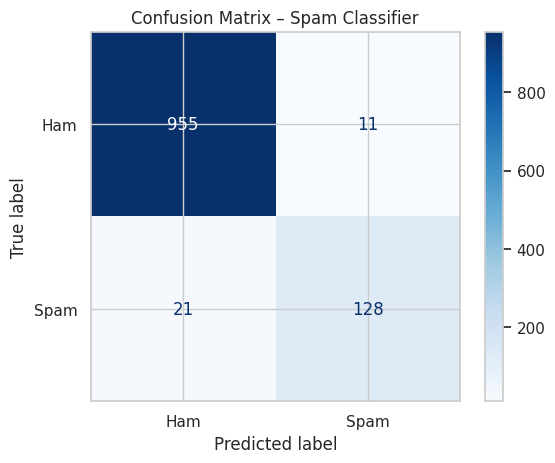

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – Spam Classifier")
plt.show()

# ROC Curve

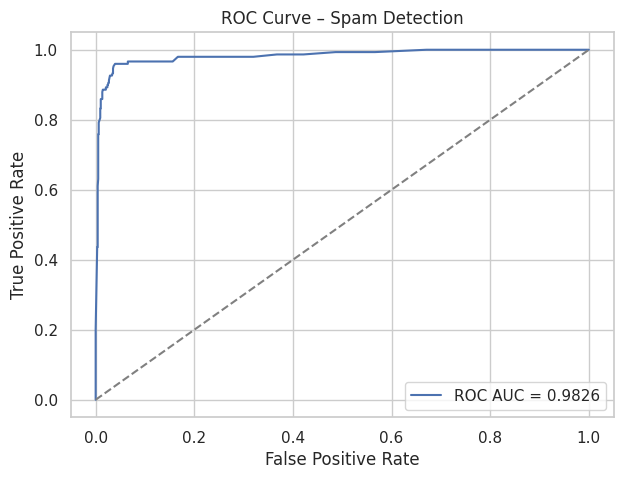

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, y_proba):.4f}')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Spam Detection')
plt.legend()
plt.show()

# Save the final calibrated model

In [ ]:
joblib.dump(calibrated_spam, "spam_classifier_calibrated.joblib")
print("Model saved as spam_classifier_calibrated.joblib")

Model saved as spam_classifier_calibrated.joblib


# Quick Inference Example Function

In [ ]:
def predict_spam(texts):
    results = []
    for text in texts:
        cleaned = professional_clean(text)
        feats = pd.DataFrame([{
            'clean_text': cleaned,
            'length': len(cleaned),
            'word_count': len(cleaned.split()),
            'has_free': 1 if 'free' in cleaned.lower() else 0,
            'has_win': 1 if any(w in cleaned.lower() for w in ['win','won','prize']) else 0,
            'exclamation': text.count('!')
        }])
        proba = calibrated_spam.predict_proba(feats)[0][1]
        label = "Spam" if proba > 0.5 else "Ham"
        results.append((label, round(proba, 4)))
    return results

# Test examples
examples = [
    "WINNER!! You are selected for a free £1000 prize. Claim now!",
    "Hey bro, are we still meeting at 7 pm tonight?",
    "Congratulations! Your mobile number has won £2000 prize. Text YES to 12345",
    "Just checking in, how's everything going?"
]

for txt, (lbl, prob) in zip(examples, predict_spam(examples)):
    print(f"{lbl:>6}  ({prob:.1%})  -  {txt}")

  Spam  (98.4%)  -  WINNER!! You are selected for a free £1000 prize. Claim now!
   Ham  (0.0%)  -  Hey bro, are we still meeting at 7 pm tonight?
  Spam  (95.8%)  -  Congratulations! Your mobile number has won £2000 prize. Text YES to 12345
   Ham  (0.0%)  -  Just checking in, how's everything going?
